# Lip Reading — ResNet18 + GRU (RGB)

## Project Overview
End-to-end **lip reading** classifier trained on the **MIRACL-VC1** dataset.
Each video sample is a short sequence of lip-region frames; the model must predict which of **10 words** is being spoken.

### Architecture
| Component | Details |
|---|---|
| Feature extractor | ResNet18 (ImageNet pretrained, per-frame) |
| Temporal model | Bidirectional GRU (hidden=128) |
| Input | RGB frames 64×64, padded to 22 frames |
| Output | 10-class softmax |

### Training strategy
- **Epochs 1–10**: CNN fully frozen, only GRU + classifier trained.
- **Epochs 11–30**: ResNet18 `layer4` unfrozen with a lower learning rate (1e-4).
- Optimizer: AdamW | Scheduler: ReduceLROnPlateau | Label smoothing: 0.05

### Speaker-independent split
| Split | Speakers |
|---|---|
| Train | 7 Females + 3 Males |
| Val | 1 Female + 1 Male |
| Test | 2 Females + 1 Male |

### Dataset
Preprocessed RGB frames (64×64) derived from MIRACL-VC1 dataset


In [1]:
# =========================
# SETUP — paths + config
# =========================
from pathlib import Path
import os
import random
import numpy as np
import torch

PREPROC_ROOT = Path("/kaggle/input/datasets/riccardodemo/preprocessed-data-rgb-64x64/PREPROCESSED_DATA_RGB_64x64")
assert PREPROC_ROOT.exists(), f"PREPROC_ROOT not found: {PREPROC_ROOT}"

BATCH_SIZE       = 8
NUM_WORKERS      = 2
PIN_MEMORY       = True
MAX_FRAMES       = None
UNIFORM_SAMPLING = 22   # max frames in the dataset — keeps all frames

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PREPROC_ROOT:", PREPROC_ROOT)


Device: cuda
PREPROC_ROOT: /kaggle/input/datasets/riccardodemo/preprocessed-data-rgb-64x64/PREPROCESSED_DATA_RGB_64x64


In [2]:
# =========================
# CLASSES + SPEAKER SPLIT
# =========================

# Classes correspond to folders words/01 through words/10
WORDS     = [f"{i:02d}" for i in range(1, 11)]  # ["01", "02", ..., "10"]
word2idx  = {w: i for i, w in enumerate(WORDS)}
NUM_CLASSES = len(word2idx)

# Speaker-independent split
# Train: 7 Females + 3 Males | Val: 1F + 1M | Test: 2F + 1M
train_speakers = ["F01", "F02", "F04", "F05", "F06", "F07", "F08", "M01", "M02", "M04"]
val_speakers   = ["F09", "M07"]
test_speakers  = ["F10", "F11", "M08"]


In [3]:
# =========================
# IMPORTS
# =========================
from typing import List, Dict, Optional
from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm


In [4]:
# ============================================================
# VIDEO DATA AUGMENTATION PIPELINE
# ============================================================

def _clamp01(x: torch.Tensor) -> torch.Tensor:
    """Clamps tensor values to the [0.0, 1.0] range."""
    return x.clamp(0.0, 1.0)

def _maybe(p: float) -> bool:
    """Returns True with probability p."""
    return random.random() < p

def _ensure_tchw(video: torch.Tensor) -> tuple[torch.Tensor, tuple]:
    """
    Standardizes input video tensors to (T, C, H, W) format.
    Supports input shapes: (T, H, W), (T, 1, H, W), or (T, C, H, W).
    Returns the standardized float32 tensor and the original shape for restoration.
    """
    orig_shape = tuple(video.shape)
    if video.dim() == 3:
        video = video.unsqueeze(1)   # (T, H, W) -> (T, 1, H, W)
    elif video.dim() != 4:
        raise ValueError(f"Expected video dim 3 or 4, got {video.dim()} with shape {video.shape}")
    if video.dtype != torch.float32:
        video = video.float()
    return video, orig_shape

def _restore_shape(video_tchw: torch.Tensor, orig_shape: tuple) -> torch.Tensor:
    """Restores the tensor to its original dimensionality."""
    if len(orig_shape) == 3:
        return video_tchw[:, 0]
    return video_tchw

def spatial_aug_consistent(video_tchw: torch.Tensor, out_size=(64, 64), p=0.9) -> torch.Tensor:
    """
    Applies spatially-consistent augmentations across all frames in the sequence.
    The same random parameters (flip, rotation, shift) are used for every frame.

    Augmentations:
     - Horizontal flip (p=0.5)
     - Random rotation ±8° (p=0.5)
     - Random shift/crop with reflect padding (p=0.8)
     - Final resize to out_size
    """
    if not _maybe(p):
        return F.interpolate(video_tchw, size=out_size, mode="bilinear", align_corners=False)

    v = video_tchw
    T, C, H, W = v.shape

    # (1) Horizontal flip — consistent across the sequence
    if _maybe(0.5):
        v = torch.flip(v, dims=[3])

    # (2) Sample consistent rotation and translation parameters
    do_rot = _maybe(0.5)
    angle  = random.uniform(-8.0, 8.0) if do_rot else 0.0

    do_shift = _maybe(0.8)
    SHIFT_PAD = 5
    dx = random.randint(-SHIFT_PAD, SHIFT_PAD) if do_shift else 0
    dy = random.randint(-SHIFT_PAD, SHIFT_PAD) if do_shift else 0

    # (3) Apply transforms with reflect padding to avoid black borders
    extra_rot_pad = 8 if do_rot else 0
    pad_total = SHIFT_PAD + extra_rot_pad

    frames = []
    for t in range(T):
        img = v[t]
        if pad_total > 0:
            img = TF.pad(img, padding=[pad_total]*4, padding_mode="reflect")
        if do_rot:
            img = TF.rotate(img, angle=angle, interpolation=TF.InterpolationMode.BILINEAR, expand=False)
        top  = pad_total + dy
        left = pad_total + dx
        img  = TF.crop(img, top=top, left=left, height=H, width=W)
        frames.append(img)

    v = torch.stack(frames, dim=0)
    v = F.interpolate(v, size=out_size, mode="bilinear", align_corners=False)
    return v

def photometric_aug(video_tchw: torch.Tensor, p=0.8) -> torch.Tensor:
    """
    Applies photometric jitter as additive uniform RGB noise.
    The noise is constant across all frames to preserve temporal lighting consistency.
    """
    if not _maybe(p):
        return video_tchw
    v = video_tchw
    if _maybe(0.5):
        T, C, H, W = v.shape
        amp = 0.05  # noise range: [-0.05, +0.05]
        if C == 3:
            noise = torch.empty(3, device=v.device).uniform_(-amp, amp)
            v = v + noise.view(1, 3, 1, 1)
        else:
            noise = torch.empty(1, device=v.device).uniform_(-amp, amp)
            v = v + noise.view(1, 1, 1, 1)
    return _clamp01(v)


class LipReadingAugment:
    """
    High-level video augmentation wrapper for lip reading.
    Applies spatially-consistent spatial and photometric transforms.
    """
    def __init__(self, out_size=(64, 64), spatial_p=0.9, photo_p=0.8):
        self.out_size   = out_size
        self.spatial_p  = spatial_p
        self.photo_p    = photo_p

    def __call__(self, video: torch.Tensor) -> torch.Tensor:
        v, orig_shape = _ensure_tchw(video)
        v = _clamp01(v)
        v = spatial_aug_consistent(v, out_size=self.out_size, p=self.spatial_p)
        v = photometric_aug(v, p=self.photo_p)
        v = _clamp01(v)
        return _restore_shape(v, orig_shape)


train_aug = LipReadingAugment(out_size=(64, 64), spatial_p=0.9, photo_p=0.8)
print("Augmentation pipeline ready:", train_aug)


Augmentation pipeline ready: <__main__.LipReadingAugment object at 0x7d869a5f0f80>


In [5]:
# =========================
# SAMPLE LISTING
# =========================

def list_samples(data_root: Path, speakers: list):
    """Recursively lists all video samples for the given speakers."""
    samples = []
    for spk in speakers:
        spk_dir = data_root / spk / "words"
        if not spk_dir.exists():
            continue
        for word_id in sorted(spk_dir.iterdir()):
            if not word_id.is_dir() or word_id.name not in word2idx:
                continue
            for inst_dir in sorted(word_id.iterdir()):
                if not inst_dir.is_dir():
                    continue
                samples.append({
                    "speaker":     spk,
                    "word_id":     word_id.name,
                    "instance_id": inst_dir.name,
                    "frames_dir":  inst_dir,
                    "label":       word2idx[word_id.name],
                })
    return samples


train_samples = list_samples(PREPROC_ROOT, train_speakers)
val_samples   = list_samples(PREPROC_ROOT, val_speakers)
test_samples  = list_samples(PREPROC_ROOT, test_speakers)

print(f"Samples — train: {len(train_samples)} | val: {len(val_samples)} | test: {len(test_samples)}")


Samples — train: 1000 | val: 200 | test: 300


In [6]:
# =========================
# FRAME LOADING HELPERS
# =========================

def load_frames_sorted(frames_dir: Path) -> List[Path]:
    """Returns all image frames in a directory, sorted by filename."""
    exts   = {".png", ".jpg", ".jpeg", ".bmp"}
    frames = [p for p in frames_dir.iterdir() if p.suffix.lower() in exts]
    return sorted(frames, key=lambda p: p.name)


def uniform_sample_indices(n: int, max_t: int) -> np.ndarray:
    """Uniformly samples max_t indices from a sequence of length n."""
    return np.linspace(0, n - 1, max_t, dtype=int)


def inspect_images(samples, n_images=20):
    """Prints image size and mode statistics for a random subset of frames."""
    sizes, modes, channels = [], [], []
    count = 0
    for s in samples:
        for f in s["frames_dir"].iterdir():
            if f.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                continue
            img = Image.open(f)
            sizes.append(img.size)
            modes.append(img.mode)
            channels.append(3 if img.mode == "RGB" else 1 if img.mode == "L" else len(img.getbands()))
            count += 1
            if count >= n_images:
                break
        if count >= n_images:
            break
    print("Image sizes:",    Counter(sizes))
    print("Image modes:",    Counter(modes))
    print("Image channels:", Counter(channels))


inspect_images(train_samples, n_images=30)


Image sizes: Counter({(64, 64): 30})
Image modes: Counter({'RGB': 30})
Image channels: Counter({3: 30})


In [7]:
# =========================
# TRANSFORMS
# =========================

# Pre-transform: PIL -> float tensor in [0, 1]
img_transform_preproc = transforms.Compose([
    transforms.ToTensor()
])

# Post-transform: ImageNet normalization (applied after augmentation)
img_transform_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)


In [8]:
# =========================
# DATASET
# =========================

class MiraclLipDataset(Dataset):
    """
    Custom Dataset for the MIRACL-VC1 Lip Reading task.
    Handles frame loading, uniform temporal sampling, spatial/photometric
    augmentations, and final normalization for deep learning backbones.
    """
    def __init__(self, samples: List[Dict], transform=None,
                 max_frames: Optional[int] = None,
                 uniform_sampling: Optional[int] = None,
                 video_aug=None, post_transform=None):
        self.samples          = samples
        self.transform        = transform
        self.max_frames       = max_frames
        self.uniform_sampling = uniform_sampling
        self.video_aug        = video_aug
        self.post_transform   = post_transform
        self._pad_frame       = None

    def __len__(self):
        return len(self.samples)

    def _get_pad_frame(self, pil_size):
        """
        Returns a black padding frame that has gone through the same
        pre- and post-transforms as real frames.
        """
        if self._pad_frame is not None:
            return self._pad_frame
        black = Image.new("RGB", pil_size, (0, 0, 0))
        pad   = self.transform(black) if self.transform is not None else \
                torch.zeros(3, pil_size[1], pil_size[0], dtype=torch.float32)
        if self.post_transform is not None:
            pad = self.post_transform(pad)
        self._pad_frame = pad
        return pad

    def __getitem__(self, idx):
        s           = self.samples[idx]
        frame_paths = load_frames_sorted(s["frames_dir"])

        if len(frame_paths) == 0:
            raise RuntimeError(f"No frames found in {s['frames_dir']}")

        if self.max_frames is not None:
            frame_paths = frame_paths[:self.max_frames]

        fixed_t = self.uniform_sampling
        if fixed_t is not None and len(frame_paths) > fixed_t:
            inds        = uniform_sample_indices(len(frame_paths), fixed_t)
            frame_paths = [frame_paths[i] for i in inds]

        frames = []
        for fp in frame_paths:
            im = Image.open(fp).convert("RGB")
            if self.transform is not None:
                im = self.transform(im)   # -> [3, H, W] in [0, 1]
            frames.append(im)

        frames = torch.stack(frames, dim=0)   # (T, 3, H, W)
        length = frames.shape[0]

        # Video augmentation applied on un-normalized [0, 1] data
        if self.video_aug is not None:
            frames = self.video_aug(frames)

        # Per-frame normalization
        if self.post_transform is not None:
            frames = torch.stack(
                [self.post_transform(frames[t]) for t in range(frames.size(0))], dim=0
            )

        # Zero-pad sequences shorter than fixed_t
        if fixed_t is not None and length < fixed_t:
            pad_frame = self._get_pad_frame(pil_size=(64, 64))
            pad_stack = pad_frame.unsqueeze(0).repeat(fixed_t - length, 1, 1, 1)
            frames    = torch.cat([frames, pad_stack], dim=0)

        label = torch.tensor(s["label"], dtype=torch.long)
        return frames, length, label


def collate_fixed(batch):
    """Collate function: stacks variable-length sequences into a padded batch."""
    frames_list, lengths, labels = zip(*batch)
    x       = torch.stack(frames_list, dim=0)            # (B, T, C, H, W)
    lengths = torch.tensor(lengths, dtype=torch.long)
    labels  = torch.stack(labels, dim=0)
    return x, lengths, labels


In [9]:
# =========================
# DATALOADERS
# =========================

# 4x oversampling to increase training data variety via augmentation
train_samples_extended = train_samples * 4

train_ds = MiraclLipDataset(
    train_samples_extended,
    transform=img_transform_preproc,
    max_frames=MAX_FRAMES,
    uniform_sampling=UNIFORM_SAMPLING,
    video_aug=train_aug,
    post_transform=img_transform_norm
)
val_ds = MiraclLipDataset(
    val_samples,
    transform=img_transform_preproc,
    max_frames=MAX_FRAMES,
    uniform_sampling=UNIFORM_SAMPLING,
    video_aug=None,
    post_transform=img_transform_norm
)
test_ds = MiraclLipDataset(
    test_samples,
    transform=img_transform_preproc,
    max_frames=MAX_FRAMES,
    uniform_sampling=UNIFORM_SAMPLING,
    video_aug=None,
    post_transform=img_transform_norm
)

train_loader = DataLoader(train_ds,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fixed)
val_loader   = DataLoader(val_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fixed)
test_loader  = DataLoader(test_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fixed)

print(f"Dataset sizes — train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")


Dataset sizes — train: 4000 | val: 200 | test: 300


Batch shapes — x: torch.Size([8, 22, 3, 64, 64]) | lengths: torch.Size([8]) | y: torch.Size([8])


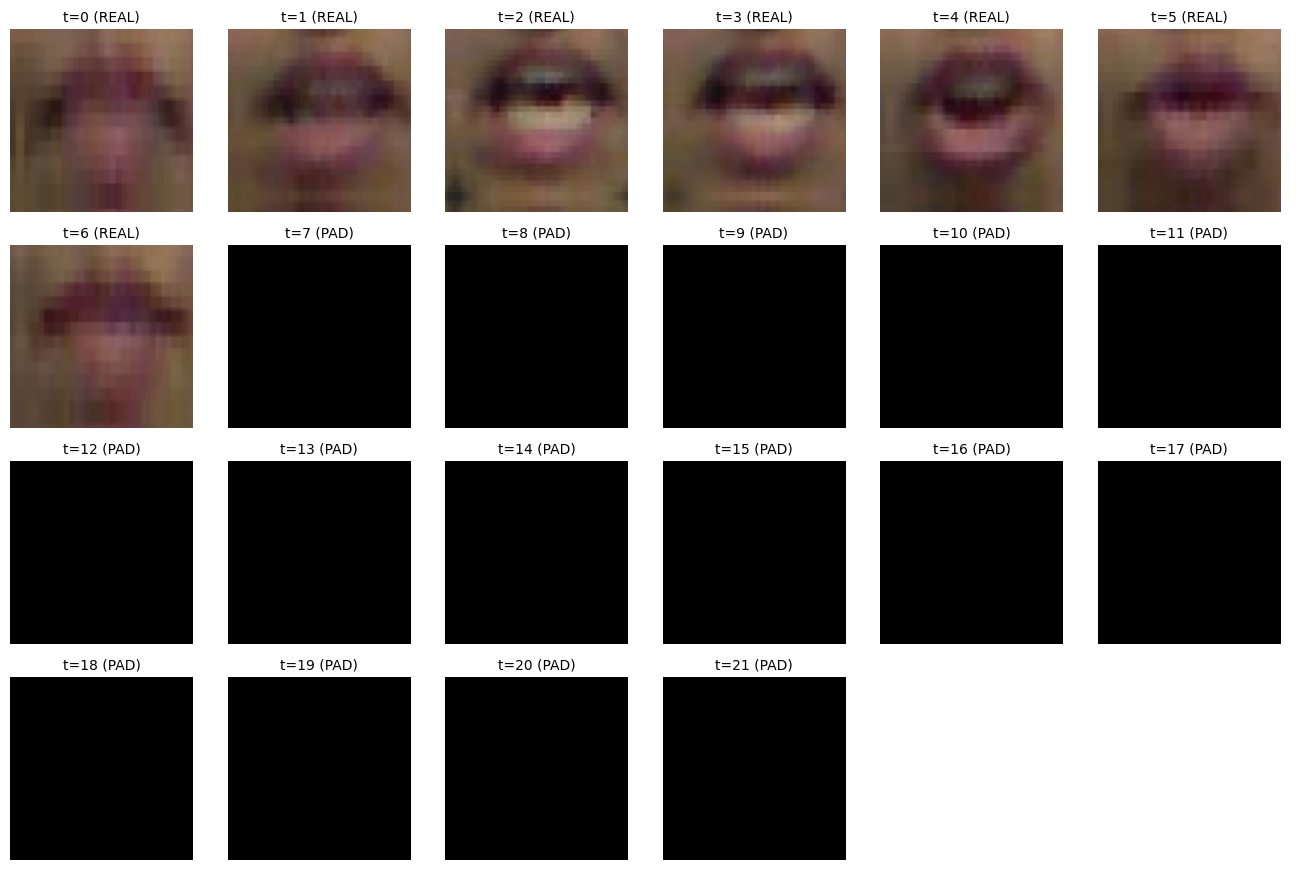

In [10]:
# =========================
# SANITY CHECK — batch shapes + frame visualisation
# =========================
import math
import matplotlib.pyplot as plt

x, lengths, y = next(iter(train_loader))
print("Batch shapes — x:", x.shape, "| lengths:", lengths.shape, "| y:", y.shape)

# De-normalise for visualisation
mean  = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3, 1, 1)
std   = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3, 1, 1)
x_vis = (x[:1] * std + mean).clamp(0, 1)   # (1, T, C, H, W)

T_total = x.shape[1]
L_real  = int(lengths[0].item())
cols    = 6
rows    = math.ceil(T_total / cols)

fig, axs = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.2 * rows))
axs = axs.flatten()
for t in range(T_total):
    img = x_vis[0, t].permute(1, 2, 0).detach().cpu().numpy()
    axs[t].imshow(img)
    axs[t].set_title(f"t={t} ({'REAL' if t < L_real else 'PAD'})", fontsize=10)
    axs[t].axis("off")
for i in range(T_total, len(axs)):
    axs[i].axis("off")
plt.tight_layout()
plt.show()


In [11]:
# =========================
# MODEL — ResNet18 + Bidirectional GRU
# =========================

class CNN_GRU_Classifier_Robust_V3(nn.Module):
    """
    ResNet18 (per-frame feature extractor) + Bidirectional GRU (temporal modeling).

    The `unfreeze_from` parameter controls which ResNet18 blocks are trainable:
        0  -> CNN fully frozen
        4  -> unfreeze layer4 only
        3  -> unfreeze layer3 + layer4
        2  -> unfreeze layer2 + layer3 + layer4
        1  -> unfreeze all layers
    """
    def __init__(
        self,
        num_classes,
        hidden_size=64,
        bidirectional=True,
        pretrained=True,
        dropout_p=0.5,
        DROPOUT_GRU=0.3,
        feature_dropout_p=0.5,
        num_gru_layers=1,
        unfreeze_from=4,
        freeze_bn_running_stats=True,
    ):
        super().__init__()

        # 1) ResNet18 backbone
        self.cnn = resnet18(weights=("DEFAULT" if pretrained else None))
        feat_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # 2) Freeze all CNN parameters, then selectively unfreeze
        for p in self.cnn.parameters():
            p.requires_grad = False

        self.unfreeze_from = int(unfreeze_from)
        if self.unfreeze_from >= 1:
            blocks = ["layer1", "layer2", "layer3", "layer4"]
            for b in blocks[self.unfreeze_from - 1:]:
                for p in getattr(self.cnn, b).parameters():
                    p.requires_grad = True

        # 3) BatchNorm running stats handling
        self.freeze_bn_running_stats = freeze_bn_running_stats

        # 4) Dropout between CNN and GRU
        self.feature_dropout = nn.Dropout(p=feature_dropout_p)

        # 5) Bidirectional GRU for temporal modeling
        self.gru = nn.GRU(
            input_size=feat_dim,
            hidden_size=hidden_size,
            num_layers=num_gru_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=DROPOUT_GRU if num_gru_layers > 1 else 0.0,
        )

        out_dim = hidden_size * (2 if bidirectional else 1)

        # 6) Final classification head
        self.dropout_fc  = nn.Dropout(p=dropout_p)
        self.classifier  = nn.Linear(out_dim, num_classes)

    def _set_bn_eval_frozen_parts(self):
        """
        Puts all BatchNorm layers in eval mode (freezes running stats),
        then restores train mode only for the unfrozen blocks.
        """
        for m in self.cnn.modules():
            if isinstance(m, nn.modules.batchnorm._BatchNorm):
                m.eval()
        if self.unfreeze_from >= 1:
            blocks = ["layer1", "layer2", "layer3", "layer4"]
            for b in blocks[self.unfreeze_from - 1:]:
                getattr(self.cnn, b).train()

    def forward(self, x, lengths):
        if self.freeze_bn_running_stats and self.training:
            self._set_bn_eval_frozen_parts()

        B, T, C, H, W = x.shape

        # Per-frame feature extraction
        x     = x.view(B * T, C, H, W)
        feats = self.cnn(x).view(B, T, -1)   # (B, T, feat_dim)
        feats = self.feature_dropout(feats)

        # Pack padded sequence for efficient GRU processing
        packed = nn.utils.rnn.pack_padded_sequence(
            feats, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, h = self.gru(packed)

        # Concatenate forward and backward last hidden states
        h_last = torch.cat([h[-2], h[-1]], dim=1) if self.gru.bidirectional else h[-1]

        h_last = self.dropout_fc(h_last)
        return self.classifier(h_last)


# 0 = CNN fully frozen | 4 = unfreeze layer4 | 3 = layer3+4 | ...
UNFREEZE_LEVEL = 0

model = CNN_GRU_Classifier_Robust_V3(
    num_classes=NUM_CLASSES,
    hidden_size=128,
    bidirectional=True,
    pretrained=True,
    dropout_p=0.5,
    DROPOUT_GRU=0.3,
    feature_dropout_p=0.5,
    num_gru_layers=1,
    unfreeze_from=UNFREEZE_LEVEL,
    freeze_bn_running_stats=True
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model      : {model.__class__.__name__}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"CNN status : {'Fully Frozen' if UNFREEZE_LEVEL == 0 else f'Unfrozen from layer{UNFREEZE_LEVEL} onwards'}")
print("\nTrainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  -> {name}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


Model      : CNN_GRU_Classifier_Robust_V3
Total params    : 11,672,138
Trainable params: 495,626
CNN status : Fully Frozen

Trainable parameters:
  -> gru.weight_ih_l0
  -> gru.weight_hh_l0
  -> gru.bias_ih_l0
  -> gru.bias_hh_l0
  -> gru.weight_ih_l0_reverse
  -> gru.weight_hh_l0_reverse
  -> gru.bias_ih_l0_reverse
  -> gru.bias_hh_l0_reverse
  -> classifier.weight
  -> classifier.bias


In [12]:
# =========================
# TRAINING UTILITIES
# =========================

def run_epoch(model, loader, optimizer=None, optimizers=None, grad_clip=None, criterion=None):
    """Runs one training or validation epoch. Accepts one or multiple optimizers."""
    if optimizers is None:
        optimizers = [optimizer] if optimizer is not None else None

    is_train = optimizers is not None
    model.train(is_train)

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    total_loss, total_correct, total_count = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for x, lengths, y in tqdm(loader, leave=False):
            x, y, lengths = x.to(device, non_blocking=True), y.to(device, non_blocking=True), lengths.to(device, non_blocking=True)

            logits = model(x, lengths)
            loss   = criterion(logits, y)

            if is_train:
                for opt in optimizers:
                    opt.zero_grad(set_to_none=True)
                loss.backward()
                if grad_clip is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                for opt in optimizers:
                    opt.step()

            total_loss    += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count   += x.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def set_cnn_trainable(model: nn.Module, unfreeze_from: int):
    """Dynamically freezes/unfreezes ResNet18 blocks during training."""
    for p in model.cnn.parameters():
        p.requires_grad = False
    if unfreeze_from >= 1:
        blocks = ["layer1", "layer2", "layer3", "layer4"]
        for b in blocks[unfreeze_from - 1:]:
            for p in getattr(model.cnn, b).parameters():
                p.requires_grad = True
    if hasattr(model, "unfreeze_from"):
        model.unfreeze_from = int(unfreeze_from)


[Epoch 01] train loss=2.2462 acc=0.1820 | val loss=2.1352 acc=0.2400 | lr_rnn=1.00e-03 lr_cnn=1.00e-04


[Epoch 02] train loss=1.8218 acc=0.3780 | val loss=1.9052 acc=0.2550 | lr_rnn=1.00e-03 lr_cnn=1.00e-04


[Epoch 03] train loss=1.5140 acc=0.5015 | val loss=1.8531 acc=0.3400 | lr_rnn=1.00e-03 lr_cnn=1.00e-04


[Epoch 04] train loss=1.3502 acc=0.5733 | val loss=1.8285 acc=0.3900 | lr_rnn=1.00e-03 lr_cnn=1.00e-04


[Epoch 05] train loss=1.2360 acc=0.6225 | val loss=1.7641 acc=0.4100 | lr_rnn=1.00e-03 lr_cnn=1.00e-04


...

[Epoch 26] train loss=0.3085 acc=0.9968 | val loss=1.5340 acc=0.6150 | lr_rnn=5.00e-04 lr_cnn=5.00e-05


[Epoch 27] train loss=0.3065 acc=0.9968 | val loss=1.7756 acc=0.5050 | lr_rnn=5.00e-04 lr_cnn=5.00e-05


[Epoch 28] train loss=0.3043 acc=0.9980 | val loss=1.5081 acc=0.5900 | lr_rnn=2.50e-04 lr_cnn=2.50e-05


[Epoch 29] train loss=0.2985 acc=0.9990 | val loss=1.3545 acc=0.6150 | lr_rnn=2.50e-04 lr_cnn=2.50e-05


[Epoch 30] train loss=0.2967 acc=0.9985 | val loss=1.4804 acc=0.6000 | lr_rnn=2.50e-04 lr_cnn=2.50e-05

Best validation accuracy: 0.6450
Best model saved to: /kaggle/working/best_model.pt


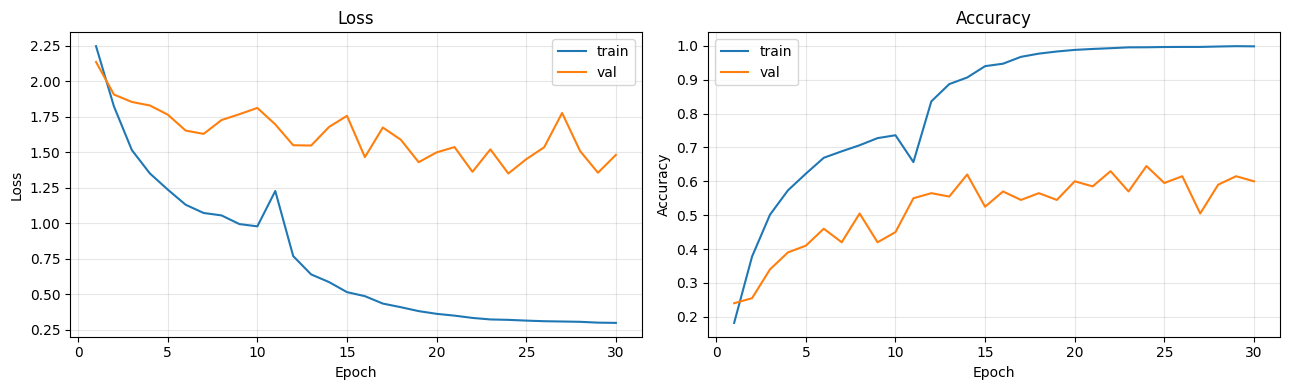

In [13]:
# =========================
# TRAINING LOOP
# =========================
from torch.optim.lr_scheduler import ReduceLROnPlateau

FREEZE_CNN_EPOCHS = 10
LR_RNN            = 1e-3
LR_CNN            = 1e-4
WEIGHT_DECAY      = 1e-4
EPOCHS            = 30

# Phase 1: CNN frozen — train only GRU + classifier
set_cnn_trainable(model, unfreeze_from=0)

optimizer = torch.optim.AdamW([
    {"params": list(model.gru.parameters()) + list(model.classifier.parameters()),
     "lr": LR_RNN, "weight_decay": WEIGHT_DECAY},
    {"params": model.cnn.layer4.parameters(),
     "lr": LR_CNN, "weight_decay": WEIGHT_DECAY},
])

scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

best_val_acc = 0.0
best_path    = "/kaggle/working/best_model.pt"
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):

    # Phase 2: unfreeze layer4 after FREEZE_CNN_EPOCHS epochs
    if epoch == FREEZE_CNN_EPOCHS + 1:
        set_cnn_trainable(model, unfreeze_from=4)
        print(f"[Epoch {epoch:02d}] CNN layer4 unfrozen (lr_cnn={LR_CNN})")

    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer, grad_clip=1.0, criterion=criterion)
    val_loss,   val_acc   = run_epoch(model, val_loader,   optimizer=None,      criterion=criterion)

    scheduler.step(val_loss)

    lr_rnn = optimizer.param_groups[0]["lr"]
    lr_cnn = optimizer.param_groups[1]["lr"]

    train_losses.append(train_loss);  val_losses.append(val_loss)
    train_accs.append(train_acc);     val_accs.append(val_acc)

    print(f"[Epoch {epoch:02d}] "
          f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"lr_rnn={lr_rnn:.2e} lr_cnn={lr_cnn:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Best model saved to: {best_path}")

# Training curves
epochs_range = list(range(1, EPOCHS + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(epochs_range, train_losses, label="train"); ax1.plot(epochs_range, val_losses, label="val")
ax1.set(title="Loss", xlabel="Epoch", ylabel="Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs_range, train_accs,   label="train"); ax2.plot(epochs_range, val_accs,   label="val")
ax2.set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Loaded best model from: /kaggle/working/best_model.pt

Test loss : 1.3829
Test accuracy : 0.6000

Classification Report:
              precision    recall  f1-score   support

       Begin     0.4091    0.3000    0.3462        30
      Choose     0.7600    0.6333    0.6909        30
  Connection     0.9091    0.6667    0.7692        30
  Navigation     0.3333    0.5000    0.4000        30
        Next     0.4634    0.6333    0.5352        30
    Previous     0.4643    0.4333    0.4483        30
       Start     0.7419    0.7667    0.7541        30
        Stop     0.8824    0.5000    0.6383        30
       Hello     0.9333    0.9333    0.9333        30
        Well     0.4872    0.6333    0.5507        30

    accuracy                         0.6000       300
   macro avg     0.6384    0.6000    0.6066       300
weighted avg     0.6384    0.6000    0.6066       300



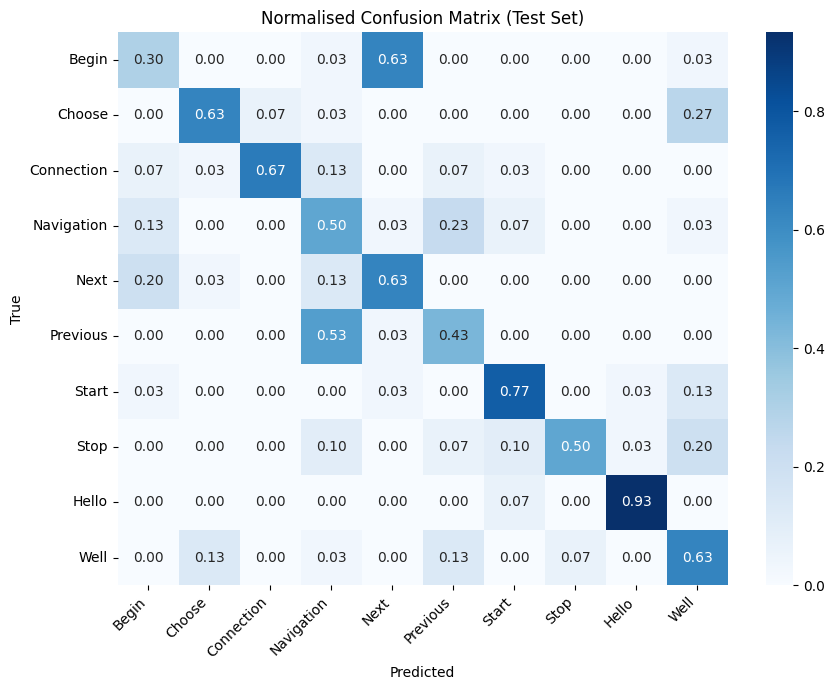

In [14]:
# =========================
# TEST SET EVALUATION
# =========================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

WORD_NAMES = ["Begin", "Choose", "Connection", "Navigation", "Next",
              "Previous", "Start", "Stop", "Hello", "Well"]

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
print("Loaded best model from:", best_path)

all_preds, all_labels = [], []
test_loss, test_correct, test_count = 0.0, 0, 0

with torch.no_grad():
    for x, lengths, y in test_loader:
        x, y, lengths = x.to(device, non_blocking=True), y.to(device, non_blocking=True), lengths.to(device, non_blocking=True)
        logits = model(x, lengths)
        preds  = logits.argmax(dim=1)
        test_loss    += F.cross_entropy(logits, y).item() * x.size(0)
        test_correct += (preds == y).sum().item()
        test_count   += x.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

test_loss /= max(test_count, 1)
test_acc   = test_correct / max(test_count, 1)
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f"\nTest loss : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=WORD_NAMES, digits=4))

# Normalised confusion matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=WORD_NAMES, yticklabels=WORD_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Normalised Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
